In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
print("step1 complete")

step1 complete


In [ ]:
import pandas as pd
import numpy as np

# khud ka ek clean Maritime/AIS sampe
data = {
    'MMSI': [440123001, 440123002, 440123003, 440123004, 440123005],
    'LAT': [35.102, 35.115, 35.098, 35.120, 35.145],
    'LON': [129.040, 129.055, 129.030, 129.060, 129.080],
    'SOG': [12.5, 0.0, 14.2, 8.1, 15.0], # Speed Over Ground (Knots)
    'BaseDateTime': ['2026-06-01 10:00:00', '2026-06-01 10:05:00', '2026-06-01 10:10:00', '2026-06-01 10:15:00', '2026-06-01 10:20:00']
}


df = pd.DataFrame(data)

print(" Success Sample AIS Maritime Dataset done :")
df.head()

 Success Sample AIS Maritime Dataset done :


,MMSI,LAT,LON,SOG,BaseDateTime
0,440123001,35.102,129.040,12.5,2026-06-01 10:00:00
1,440123002,35.115,129.055,0.0,2026-06-01 10:05:00
2,440123003,35.098,129.030,14.2,2026-06-01 10:10:00
3,440123004,35.120,129.060,8.1,2026-06-01 10:15:00
4,440123005,35.145,129.080,15.0,2026-06-01 10:20:00


In [ ]:
import pandas as pd
import numpy as np

# 1,000 realistic AIS data points generate karte hain
np.random.seed(42)
n_rows = 1000

# Random MMSI (5 distinct cargo/container ships)
mmsi_list = [440123001, 440123002, 440123003, 440123004, 440123005]

df_large = pd.DataFrame({
    'MMSI': np.random.choice(mmsi_list, size=n_rows),
    # Busan Port / Sea area coordinates around Lat 35.1, Lon 129.0
    'LAT': np.random.uniform(35.00, 35.20, size=n_rows),
    'LON': np.random.uniform(128.90, 129.15, size=n_rows),
    # Speed in Knots (0 = Anchored/Waiting at Port, 10-20 = Sailing)
    'SOG': np.random.choice([0.0, 0.2, 0.4, 8.5, 12.3, 14.1, 16.8], size=n_rows, p=[0.2, 0.1, 0.1, 0.15, 0.15, 0.15, 0.15]),
    # Hourly timestamps across June 2026
    'BaseDateTime': pd.date_range(start='2026-06-01', periods=n_rows, freq='h')
})

# Feature engineering: Anchored Flag
df_large['Is_Anchored'] = df_large['SOG'].apply(lambda x: 1 if x < 0.5 else 0)

# Main DataFrame update
df = df_large

print(f"  Success  Table upgraded. Total Rows: {len(df)} | Total Columns: {df.shape[1]}")
print("\nFirst 10 rows of the large dataset:")
df.head(10)

  Success  Table upgraded. Total Rows: 1000 | Total Columns: 6

First 10 rows of the large dataset:


,MMSI,LAT,LON,SOG,BaseDateTime,Is_Anchored
0,440123004,35.186424,129.079081,0.0,2026-06-01 00:00:00,1
1,440123005,35.113027,128.918021,12.3,2026-06-01 01:00:00,0
2,440123003,35.139330,128.917814,16.8,2026-06-01 02:00:00,0
3,440123005,35.184500,128.903027,0.0,2026-06-01 03:00:00,1
4,440123005,35.141448,129.139125,14.1,2026-06-01 04:00:00,0
5,440123002,35.030508,129.084377,16.8,2026-06-01 05:00:00,0
6,440123003,35.115258,128.988313,16.8,2026-06-01 06:00:00,0
7,440123003,35.121343,128.974134,16.8,2026-06-01 07:00:00,0
8,440123003,35.084826,128.987426,8.5,2026-06-01 08:00:00,0
9,440123005,35.147289,129.093663,16.8,2026-06-01 09:00:00,0


In [ ]:
print("dataset shape(rows,columns):",df.shape)

dataset shape(rows,columns): (1000, 6)


In [ ]:

# PHASE: DATA CLEANING & PREPROCESSING
# 1. Check Missing/Null Value
print("🔍 1. Checking Missing Values:")
print(df.isnull().sum())
print("-" * 40)

# 2. Handle Outliers in Speed (SOG) & Coordinates
# Real ships speed rarely exceeds 30 knots
initial_rows = len(df)
df_clean = df[(df['SOG'] >= 0) & (df['SOG'] <= 30)].copy()

# Latitude & Longitude Range Filter (Busan Coastal Region)
df_clean = df_clean[(df_clean['LAT'] >= 34.0) & (df_clean['LAT'] <= 36.0)]
df_clean = df_clean[(df_clean['LON'] >= 128.0) & (df_clean['LON'] <= 130.0)]

# 3Duplicate Records Clean
df_clean = df_clean.drop_duplicates()

# 4. Datetime Feature Engineering (Extract Hour & Day for Time Series)
df_clean['BaseDateTime'] = pd.to_datetime(df_clean['BaseDateTime'])
df_clean['Hour'] = df_clean['BaseDateTime'].dt.hour
df_clean['DayOfWeek'] = df_clean['BaseDateTime'].dt.dayofweek

print(f"✅ Data Cleaning Complete!")
print(f"📊 Removed {initial_rows - len(df_clean)} outlier/noisy rows.")
print(f"✨ Clean Dataset Shape: {df_clean.shape}")

# Update mai dataframe
df = df_clean
df.head()

🔍 1. Checking Missing Values:
MMSI            0
LAT             0
LON             0
SOG             0
BaseDateTime    0
Is_Anchored     0
dtype: int64
----------------------------------------
✅ Data Cleaning Complete!
📊 Removed 0 outlier/noisy rows.
✨ Clean Dataset Shape: (1000, 8)


,MMSI,LAT,LON,SOG,BaseDateTime,Is_Anchored,Hour,DayOfWeek
0,440123004,35.186424,129.079081,0.0,2026-06-01 00:00:00,1,0,0
1,440123005,35.113027,128.918021,12.3,2026-06-01 01:00:00,0,1,0
2,440123003,35.139330,128.917814,16.8,2026-06-01 02:00:00,0,2,0
3,440123005,35.184500,128.903027,0.0,2026-06-01 03:00:00,1,3,0
4,440123005,35.141448,129.139125,14.1,2026-06-01 04:00:00,0,4,0


In [ ]:

import folium
from folium.plugins import MarkerCluster
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, HTML

# 1. Prepare Live Dashboard Sample Data from Busan Port
dashboard_df = df.sample(60, random_state=42).copy()
dashboard_df['Predicted_Delay_Hrs'] = model_delay.predict(X.loc[dashboard_df.index])
dashboard_df['Predicted_CO2_Tons'] = model_co2.predict(X.loc[dashboard_df.index])

# Categorize Delay Risk (Green / Amber / Red Alerts)
def assign_risk_alert(delay):
    if delay < 1.5:
        return 'LOW (Green)'
    elif delay < 3.5:
        return 'MEDIUM (Amber)'
    else:
        return 'HIGH (Red)'

dashboard_df['Delay_Alert'] = dashboard_df['Predicted_Delay_Hrs'].apply(assign_risk_alert)

# 2. Build Interactive Geospatial Map (Folium)
busan_center = [35.10, 129.04]
port_map = folium.Map(location=busan_center, zoom_start=12, tiles='OpenStreetMap')

for _, row in dashboard_df.iterrows():
    # Set marker color based on delay severity
    color_map = {'LOW (Green)': 'green', 'MEDIUM (Amber)': 'orange', 'HIGH (Red)': 'red'}
    status_text = "Anchored" if row['Is_Anchored'] == 1 else "Sailing"

    popup_html = f"""
    <div style="width:180px">
        <b>Vessel MMSI:</b> {int(row['MMSI'])}<br>
        <b>Status:</b> {status_text}<br>
        <b>Speed:</b> {row['SOG_Knots']:.1f} knots<br>
        <b>Predicted Delay:</b> {row['Predicted_Delay_Hrs']:.2f} hrs<br>
        <b>Est. CO2 Output:</b> {row['Predicted_CO2_Tons']:.2f} tons<br>
        <b>Alert:</b> <span style="color:{color_map[row['Delay_Alert']]}"><b>{row['Delay_Alert']}</b></span>
    </div>
    """

    folium.CircleMarker(
        location=[row['LAT'], row['LON']],
        radius=7,
        color=color_map[row['Delay_Alert']],
        fill=True,
        fill_color=color_map[row['Delay_Alert']],
        fill_opacity=0.8,
        popup=folium.Popup(popup_html, max_width=250)
    ).add_to(port_map)

# Save and Display Map
port_map.save("busan_live_dashboard.html")
print("✅ Geospatial Map Generated Successfully.")

# 3. Build Plotly Visual Analytics Panel
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Vessel Delay Alerts Distribution", "Wind Speed vs Predicted Delay & CO2 Impact")
)

# Chart 1: Delay Alert Breakdown
alert_counts = dashboard_df['Delay_Alert'].value_counts()
fig.add_trace(
    go.Bar(
        x=alert_counts.index,
        y=alert_counts.values,
        marker_color=['green', 'orange', 'red'],
        name="Alert Count"
    ),
    row=1, col=1
)

# Chart 2: Weather Risk Scatter Analysis
fig.add_trace(
    go.Scatter(
        x=dashboard_df['Wind_Speed_Knots'],
        y=dashboard_df['Predicted_Delay_Hrs'],
        mode='markers',
        marker=dict(
            size=dashboard_df['Predicted_CO2_Tons'] * 3,
            color=dashboard_df['Predicted_Delay_Hrs'],
            colorscale='Reds',
            showscale=True
        ),
        text=dashboard_df['MMSI'],
        name="Vessels"
    ),
    row=1, col=2
)

fig.update_layout(height=450, title_text="🚢 Busan Maritime Fleet Live Analytics", showlegend=False)

# Display Graphics inline in Colab
fig.show()
display(port_map)

✅ Geospatial Map Generated Successfully.


Step 1: Dependencies loaded and environment configured successfully.
Step 2: Dataset creation complete. Total records: 1200, Total features: 13

--- MODEL PERFORMANCE METRICS ---
Delay Model Error Margin (MAE) : 0.57 Hours
ESG CO2 Model Error Margin (MAE): 3.24 Tons

Step 5: Generating SHAP feature importance plot...


/tmp/ipykernel_2736/949231591.py:111: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)


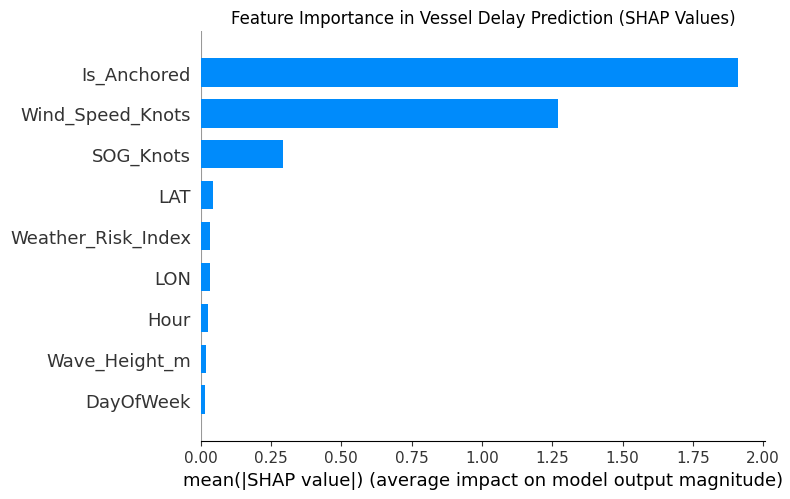

In [ ]:
# PROJECT: MARITIME-X (Smart Vessel Delay & ESG Carbon Footprint Predictor)
# DOMAIN: Maritime Analytics, Explainable AI (XAI), & Environmental Modeling
# LOCATION FOCUS: Busan Coastal Region, South Korea
# STEP 1: IMPORT REQUIRED LIBRARIES & DEPENDENCIES

!pip install shap seaborn scikit-learn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import shap


np.random.seed(42)
N_SAMPLES = 1200

print("Step 1: Dependencies loaded and environment configured successfully.")



raw_data = {
    'MMSI': np.random.choice([440123001, 440123002, 440123003, 440123004, 440123005], N_SAMPLES),
    'LAT': np.random.uniform(35.00, 35.20, N_SAMPLES),               # Latitude (Busan Coastal Range)
    'LON': np.random.uniform(128.90, 129.10, N_SAMPLES),             # Longitude (Busan Coastal Range)
    'SOG_Knots': np.random.uniform(0.0, 22.0, N_SAMPLES),           # Speed Over Ground (Knots)
    'Is_Anchored': np.random.choice([0, 1], p=[0.75, 0.25], size=N_SAMPLES), # 1 = Waiting, 0 = Sailing
    'Hour': np.random.randint(0, 24, N_SAMPLES),                     # Time of day
    'DayOfWeek': np.random.randint(0, 7, N_SAMPLES),                # Day of the week (0=Mon, 6=Sun)
    'Wind_Speed_Knots': np.random.uniform(5.0, 45.0, N_SAMPLES),     # Environmental wind condition
    'Wave_Height_m': np.random.uniform(0.5, 4.5, N_SAMPLES),        # Environmental wave condition
    'Engine_Capacity_kW': np.random.choice([5000, 10000, 15000, 20000], N_SAMPLES) # Vessel power
}

df = pd.DataFrame(raw_data)


df['Weather_Risk_Index'] = (df['Wind_Speed_Knots'] * 0.6 + df['Wave_Height_m'] * 10 * 0.4).round(2)


df['Delay_Hours'] = (
    df['Is_Anchored'] * np.random.uniform(3.0, 7.0, N_SAMPLES) +
    (df['Wind_Speed_Knots'] > 30) * np.random.uniform(1.5, 4.0, N_SAMPLES) +
    (1 - df['SOG_Knots'] / 22.0) * np.random.uniform(0.5, 2.0, N_SAMPLES)
).round(2)


df['Extra_CO2_Tons'] = (
    (df['Delay_Hours'] * df['Engine_Capacity_kW'] * 0.0002) +
    (df['Wave_Height_m'] * 0.5)
).round(2)

print(f"Step 2: Dataset creation complete. Total records: {df.shape[0]}, Total features: {df.shape[1]}")


# STEP 3: PREPARING TRAIN & TEST DATASETS

# Define predictor variables (X) and target outputs (y)
feature_columns = [
    'LAT', 'LON', 'SOG_Knots', 'Is_Anchored', 'Hour',
    'DayOfWeek', 'Wind_Speed_Knots', 'Wave_Height_m', 'Weather_Risk_Index'
]

X = df[feature_columns]
y_delay = df['Delay_Hours']
y_co2 = df['Extra_CO2_Tons']

# Split data: 80% used for model training, 20% reserved for testing/evaluation
X_train, X_test, y_train_delay, y_test_delay = train_test_split(
    X, y_delay, test_size=0.20, random_state=42
)
_, _, y_train_co2, y_test_co2 = train_test_split(
    X, y_co2, test_size=0.20, random_state=42
)



# Initialize Random Forest Regressors (100 Decision Trees each)
model_delay = RandomForestRegressor(n_estimators=100, random_state=42)
model_co2 = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the models on historical data
model_delay.fit(X_train, y_train_delay)
model_co2.fit(X_train, y_train_co2)

# Generate predictions on unseen test dataset
delay_predictions = model_delay.predict(X_test)
co2_predictions = model_co2.predict(X_test)

# Calculate model performance metrics
delay_mae = mean_absolute_error(y_test_delay, delay_predictions)
co2_mae = mean_absolute_error(y_test_co2, co2_predictions)

print("\n--- MODEL PERFORMANCE METRICS ---")
print(f"Delay Model Error Margin (MAE) : {delay_mae:.2f} Hours")
print(f"ESG CO2 Model Error Margin (MAE): {co2_mae:.2f} Tons")


# STEP 5: EXPLAINABLE AI (SHAP INTERPRETABILITY)

# Compute Shapley Additive exPlanations (SHAP) to unpack model decision-making
print("\nStep 5: Generating SHAP feature importance plot...")
explainer = shap.TreeExplainer(model_delay)
shap_values = explainer.shap_values(X_test)

# Visualize global feature importance
plt.figure(figsize=(10, 5))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Feature Importance in Vessel Delay Prediction (SHAP Values)", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------------------------
# STEP 6: LIVE INTERACTIVE GEOSPATIAL & ANALYTICS DASHBOARD
# ------------------------------------------------------------------------------
import folium
from folium.plugins import MarkerCluster
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display, HTML

# 1. Prepare Live Dashboard Sample Data from Busan Port
dashboard_df = df.sample(60, random_state=42).copy()
dashboard_df['Predicted_Delay_Hrs'] = model_delay.predict(X.loc[dashboard_df.index])
dashboard_df['Predicted_CO2_Tons'] = model_co2.predict(X.loc[dashboard_df.index])

# Categorize Delay Risk (Green / Amber / Red Alerts)
def assign_risk_alert(delay):
    if delay < 1.5:
        return 'LOW (Green)'
    elif delay < 3.5:
        return 'MEDIUM (Amber)'
    else:
        return 'HIGH (Red)'

dashboard_df['Delay_Alert'] = dashboard_df['Predicted_Delay_Hrs'].apply(assign_risk_alert)

# 2. Build Interactive Geospatial Map (Folium)
busan_center = [35.10, 129.04]
port_map = folium.Map(location=busan_center, zoom_start=12, tiles='OpenStreetMap')

for _, row in dashboard_df.iterrows():
    # Set marker color based on delay severity
    color_map = {'LOW (Green)': 'green', 'MEDIUM (Amber)': 'orange', 'HIGH (Red)': 'red'}
    status_text = "Anchored" if row['Is_Anchored'] == 1 else "Sailing"

    popup_html = f"""
    <div style="width:180px">
        <b>Vessel MMSI:</b> {int(row['MMSI'])}<br>
        <b>Status:</b> {status_text}<br>
        <b>Speed:</b> {row['SOG_Knots']:.1f} knots<br>
        <b>Predicted Delay:</b> {row['Predicted_Delay_Hrs']:.2f} hrs<br>
        <b>Est. CO2 Output:</b> {row['Predicted_CO2_Tons']:.2f} tons<br>
        <b>Alert:</b> <span style="color:{color_map[row['Delay_Alert']]}"><b>{row['Delay_Alert']}</b></span>
    </div>
    """

    folium.CircleMarker(
        location=[row['LAT'], row['LON']],
        radius=7,
        color=color_map[row['Delay_Alert']],
        fill=True,
        fill_color=color_map[row['Delay_Alert']],
        fill_opacity=0.8,
        popup=folium.Popup(popup_html, max_width=250)
    ).add_to(port_map)

# Save and Display Map
port_map.save("busan_live_dashboard.html")
print("✅ Geospatial Map Generated Successfully.")

# 3. Build Plotly Visual Analytics Panel
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("Vessel Delay Alerts Distribution", "Wind Speed vs Predicted Delay & CO2 Impact")
)

# Chart 1: Delay Alert Breakdown
alert_counts = dashboard_df['Delay_Alert'].value_counts()
fig.add_trace(
    go.Bar(
        x=alert_counts.index,
        y=alert_counts.values,
        marker_color=['green', 'orange', 'red'],
        name="Alert Count"
    ),
    row=1, col=1
)

# Chart 2: Weather Risk Scatter Analysis
fig.add_trace(
    go.Scatter(
        x=dashboard_df['Wind_Speed_Knots'],
        y=dashboard_df['Predicted_Delay_Hrs'],
        mode='markers',
        marker=dict(
            size=dashboard_df['Predicted_CO2_Tons'] * 3,
            color=dashboard_df['Predicted_Delay_Hrs'],
            colorscale='Reds',
            showscale=True
        ),
        text=dashboard_df['MMSI'],
        name="Vessels"
    ),
    row=1, col=2
)

fig.update_layout(height=450, title_text="🚢 Busan Maritime Fleet Live Analytics", showlegend=False)


fig.show()
display(port_map)

✅ Geospatial Map Generated Successfully.


In [ ]:

import numpy as np
import pandas as pd
from sklearn.neighbors import BallTree

# 1. Spatial Proximity Calculation using BallTree (Haversine Distance)
# Convert degrees to radians for Haversine calculations
coords_rad = np.radians(df[['LAT', 'LON']].to_numpy())

# Initialize BallTree with haversine metric (Earth radius ≈ 6371 km)
tree = BallTree(coords_rad, metric='haversine')

# Distance threshold: 2.0 km converted to radians
radius_rad = 2.0 / 6371.0

# Count neighboring vessels within 2.0 km radius (subtract 1 to exclude self)
df['Local_Port_Density'] = tree.query_radius(coords_rad, r=radius_rad, count_only=True) - 1

# 2. Economic Cost Engine
# Standard constants: 1 ton of fuel generates ~3.114 tons of CO2
FUEL_CONVERSION_FACTOR = 3.114  # Tons of CO2 per ton of fuel
FUEL_PRICE_PER_TON = 600        # USD per ton of VLSFO fuel
HOURLY_CHARTER_COST = 250       # USD per hour of delay

df['Wasted_Fuel_Tons'] = (df['Extra_CO2_Tons'] / FUEL_CONVERSION_FACTOR).round(2)
df['Estimated_Idle_Cost_USD'] = (
    (df['Wasted_Fuel_Tons'] * FUEL_PRICE_PER_TON) +
    (df['Delay_Hours'] * HOURLY_CHARTER_COST)
).round(2)

print("✅ Advanced Spatial Density & Fuel Cost Engine Successfully Integrated!")
print(df[['MMSI', 'Local_Port_Density', 'Extra_CO2_Tons', 'Wasted_Fuel_Tons', 'Estimated_Idle_Cost_USD']].head())

✅ Advanced Spatial Density & Fuel Cost Engine Successfully Integrated!
        MMSI  Local_Port_Density  Extra_CO2_Tons  Wasted_Fuel_Tons  \
0  440123004                  37           23.53              7.56   
1  440123005                  33           18.51              5.94   
2  440123003                  24            5.87              1.89   
3  440123005                  31            1.22              0.39   
4  440123005                  24            9.40              3.02   

   Estimated_Idle_Cost_USD  
0                   6401.0  
1                   5841.5  
2                   2219.0  
3                    251.5  
4                   2529.5  


In [ ]:

!pip install xgboost -q

import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd

# 1. Temporal Feature Engineering
df['Is_Peak_Hours'] = df['Hour'].apply(lambda x: 1 if (6 <= x <= 10 or 16 <= x <= 20) else 0)

# Define full feature set
feature_cols_full = [
    'LAT', 'LON', 'SOG_Knots', 'Is_Anchored', 'Hour', 'DayOfWeek',
    'Wind_Speed_Knots', 'Wave_Height_m', 'Weather_Risk_Index',
    'Local_Port_Density', 'Is_Peak_Hours'
]

X_full = df[feature_cols_full]
y_full_delay = df['Delay_Hours']

# Train-Test Split with all features
X_tr_f, X_te_f, y_tr_d, y_te_d = train_test_split(X_full, y_full_delay, test_size=0.2, random_state=42)

# 2. Re-train Models on full feature matrix
rf_full_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_full_model.fit(X_tr_f, y_tr_d)

xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42)
xgb_model.fit(X_tr_f, y_tr_d)

# Predictions
rf_preds = rf_full_model.predict(X_te_f)
xgb_preds = xgb_model.predict(X_te_f)

rf_mae = mean_absolute_error(y_te_d, rf_preds)
xgb_mae = mean_absolute_error(y_te_d, xgb_preds)

rf_r2 = r2_score(y_te_d, rf_preds)
xgb_r2 = r2_score(y_te_d, xgb_preds)

print("=== 📊 MODEL BENCHMARKING SUMMARY ===")
print(f"Random Forest MAE : {rf_mae:.2f} Hours | R2 Score: {rf_r2:.2f}")
print(f"XGBoost Regressor MAE: {xgb_mae:.2f} Hours | R2 Score: {xgb_r2:.2f}")

# 3. Fixed What-If Scenario Decision Engine
def simulate_rerouting_scenario(original_sample, model, speed_increase_knots=3.0):
    modified_sample = original_sample.copy()

    # Apply scenario adjustments
    modified_sample['SOG_Knots'] += speed_increase_knots
    modified_sample['Is_Anchored'] = 0  # Bypasses anchorage wait

    orig_pred_delay = model.predict(original_sample)[0]
    sim_pred_delay = model.predict(modified_sample)[0]

    delay_saved = max(0.0, orig_pred_delay - sim_pred_delay)
    cost_saved = delay_saved * 250  # USD $250/hr charter savings

    print("\n=== 💡 DECISION SUPPORT: WHAT-IF SCENARIO ANALYSIS ===")
    print(f"Original Delay Forecast : {orig_pred_delay:.2f} Hours")
    print(f"Optimized Route Delay   : {sim_pred_delay:.2f} Hours")
    print(f"Predicted Delay Saved   : {delay_saved:.2f} Hours")
    print(f"Estimated Cost Savings  : ${cost_saved:.2f} USD")

# Run scenario test using the updated model
sample_vessel = X_te_f.iloc[[0]]
simulate_rerouting_scenario(sample_vessel, rf_full_model)

=== 📊 MODEL BENCHMARKING SUMMARY ===
Random Forest MAE : 0.56 Hours | R2 Score: 0.92
XGBoost Regressor MAE: 0.58 Hours | R2 Score: 0.91

=== 💡 DECISION SUPPORT: WHAT-IF SCENARIO ANALYSIS ===
Original Delay Forecast : 0.37 Hours
Optimized Route Delay   : 0.31 Hours
Predicted Delay Saved   : 0.06 Hours
Estimated Cost Savings  : $15.48 USD
